In [58]:
# Initialize Otter
import otter
grader = otter.Notebook("lab05.ipynb")

# Lab 05: Modeling, Loss Functions, Summary Statistics, and OLS


In this lab, you will perform modeling on a dataset containing vehicle efficiency and explore loss functions and summary statistics in the process.

To receive credit for a lab, answer all questions correctly and submit before the deadline.

You must submit this assignment to Pensive by the on-time deadline, **Tuesday, March 3rd, 11:59 PM PT**. Please read the syllabus for the Slip Day policy. As a reminder, slip days are **not** applicable on labs. **We strongly encourage you to plan to submit your work to Pensive several hours before the stated deadline.** This way, you will have ample time to contact staff for submission support. 

## Lab Walkthrough
In addition to the lab notebook, we have also released a prerecorded walkthrough video of the lab. This playlist includes a walkthrough for every question in the lab. We encourage you to reference this video as you work through the lab. Run the cell below to display the video.


**Note 1:** These videos were recorded in Spring 2023. There may be slight inconsistencies between the version you are viewing and the version used in the recording, but the content is identical.

**Note 2:** All parts of the lab can be found on this [**Playlist**](https://www.youtube.com/watch?v=ZxACr_9bQY4&list=PLQCcNQgUcDfoz1Msffiqug6-KAoAbrf9f&t=3s)

In [59]:
from IPython.display import YouTubeVideo
YouTubeVideo("v=pSBM0W860DQ", list='PLQCcNQgUcDfoz1Msffiqug6-KAoAbrf9f', listType = 'playlist')

## Collaboration Policy

Data science is a collaborative activity. While you may talk to others about the labs, we ask that you **write your solutions individually**. If you do discuss the assignments with others, please **include their names** in the following cell:

**Collaborators**: *list names here*

## Discussion 6 Mini-lecture

In Data 100, discussions will not reserve time to host mini-lectures. Instead, we will release a set of pre-recorded mini-lectures that supplement the concepts introduced in lecture. The week after a mini-lecture is released, the topics will be covered in discussion. Thus, it is important to watch these mini-lectures **before** attending the discussion section you are assigned to. Discussion 6 mini-lecture is attached below. The link is also provided [here](https://www.youtube.com/watch?v=2pStLwJDghc&list=PLQCcNQgUcDfqhtaFtgl7syP-V2dWYQ81S&index=6).

<span style="color: red; font-size: 150%;">**You must be logged into your Berkeley account on YouTube to access the video**</span>

In [60]:
YouTubeVideo("2pStLwJDghc", list = 'PLQCcNQgUcDfqhtaFtgl7syP-V2dWYQ81S')

---
## Debugging Guide

If you run into any technical issues, we highly recommend checking out the [Data 100 Debugging Guide](https://ds100.org/debugging-guide/). In this guide, you can find general questions about Jupyter notebooks / Datahub, Gradescope, and common `pandas` and `regex` errors.

<br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Predicting car efficiency with horsepower

For vehicles that run on liquid fuels, miles per gallon (MPG) is a commonly used measure of fuel efficiency, describing how many miles a car can travel using one gallon of fuel.

In this lab, you will attempt to predict MPG from a dataset using several approaches. First, we will begin with a constant model that minimizes L2 loss. Then, we will fit an Ordinary Least Squares (OLS) model to the data.


<br/>

First, let's load the data.

In [61]:
# Run this cell to load the data; no further action is needed.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set()
sns.set_context("talk")

In [62]:
# Just run this cell
vehicle_data = sns.load_dataset('mpg').dropna()
vehicle_data = vehicle_data.sort_values('horsepower', ascending=True)
vehicle_data.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan
102,26.0,4,97.0,46.0,1950,21.0,73,europe,volkswagen super beetle
244,43.1,4,90.0,48.0,1985,21.5,78,europe,volkswagen rabbit custom diesel
326,43.4,4,90.0,48.0,2335,23.7,80,europe,vw dasher (diesel)
325,44.3,4,90.0,48.0,2085,21.7,80,europe,vw rabbit c (diesel)


In [63]:
# Run this cell to define x and y array; no further action needed.
y_mpg = np.array(vehicle_data["mpg"]) # Array of total mpg values

print("mpg", y_mpg.shape)

mpg (392,)


Recall the steps of the modeling process covered in the lecture:

A. Define a **model.**

B. Choose a **loss function** and calculate the **average loss** on our dataset.

C. Find the best value of $\theta$, known as $\hat{\theta}$, that **minimizes** loss. There can be multiple such $\theta$ values.

D. Evaluate the model performance (not covered in this lab). 

We'll go through the first three steps of this process next.

<br/>
<hr style="border: 1px solid #fdb515;" />

# Question 1: MPG as a Constant Function with $L_2$ Loss

In this section, you will use the **constant model** to predict mpg. 

Let us predict any vehicle mpg using one single constant value. In other words, let's try to find the best statistic $\hat{\theta_0}$ to represent (i.e., **summarize**) mpg from our dataset.

## A: Define the model

We will define our model as the **constant model**:

$$\large
\hat{y} = \theta_0
$$

In other words, regardless of any other details (i.e., features) about the vehicle, we will always predict our mpg $\hat{y}$ as one single value: $\theta_0$.

It ignores any relationships between variables:

- For example, mpg likely depends on the vehicle itself, horsepower, weight, etc.;
- Ignoring these factors is a **simplifying assumption**.


We call the constant model a **summary statistic**, as we are determining one number that best "summarizes" a set of values.


No code to write here!

## B: Define the loss function and loss

Next, we'll define our loss function $L(y, \hat{y})$ and consequently our loss function $R(\theta_0)$.

Here we'll use $L_2$ Loss and Mean Squared Error. Let the dataset $\mathcal{D}$ be the set of observations: $\mathcal{D} = \{(y_1), \ldots, (y_n)\}$, where $y_i$ are the $i^{th}$ and mpg in our dataset.

Our $L_2$ Loss and Mean Squared Error are therefore:

$$\large L_2(y, \hat{y}) = \large (y - \hat{y})^2 = \large (y - \theta_0)^2 $$

$$\large R(\theta_0) = \large \frac{1}{n} \sum_{i=1}^n L(y_i, \hat{y}_i) = \large \frac{1}{n} \sum_{i = 1}^n(y_i - \theta_0)^2
$$

Notice that because our model is now the constant model $\hat{y} = \theta_0$, our final expressions for Loss and MSE are different from Question 1.


<br>

---

### Question 1a

Define the `mse_mpg_constant` function which computes $R(\theta_0)$ as the **Mean Squared Error** on the mpg data for a constant model with parameter $\theta_0$.


**Hints:** 
* You should use the `NumPy` arrays `y_mpg` defined at the beginning of Question 1.

In [64]:
def mse_mpg_constant(theta0):
    """
    Calculate the mean squared error on the mpg data for a constant model.
    
    Parameters
    ------------
    theta0 : fitted constant model
    
    Returns
    ------------
    The mean squared error on the mpg data for a constant model.
    """
    n = len(y_mpg)
    return np.sum((y_mpg - theta0) ** 2) / n

mse_mpg_constant(5.3) # Arbitrarily pick a = 5.3

390.0370918367347

In [65]:
grader.check("q1a")

q1a results: All test cases passed!

## C: Find the $\theta_0$ that minimizes loss

Similar to before, we'd like to try out different approaches to finding the optimal parameter $\hat{\theta_0}$ that minimizes MSE.

### Visual Solution

In the cell below, we plot the MSE for different values of $\theta_0$:

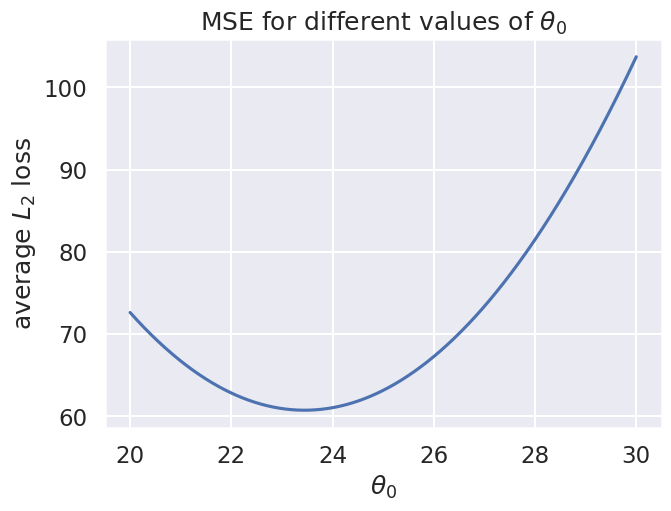

In [66]:
# Run this cell to plot MSE; no further action is needed.
theta0_values = np.linspace(20, 30, 1000)
mse = [mse_mpg_constant(theta) for theta in theta0_values]
plt.plot(theta0_values, mse)
plt.xlabel(r'$\theta_0$')
plt.ylabel('average $L_2$ loss')
plt.title(r'MSE for different values of $\theta_0$');

<br>

---

### Question 1b

Based on the above plot, without calculation, what is the value of $\theta_0$ that minimizes the MSE? Assign it to `theta0_hat_observed`.

**Note: We know that it is hard to get the exact value, so just try your best — we will give you something better than observing it in a second!**

In [67]:
theta0_hat_observed = 23.5
theta0_hat_observed

23.5

In [68]:
grader.check("q1b")

q1b results: All test cases passed!

<br/>

Now, let's use this approach to find a numerical solution to the optimal $\hat{\theta}$ that minimizes our MSE loss.

### Tutorial: `scipy.optimize.minimize`

The cell below plots some arbitrary 4th degree polynomial function. 

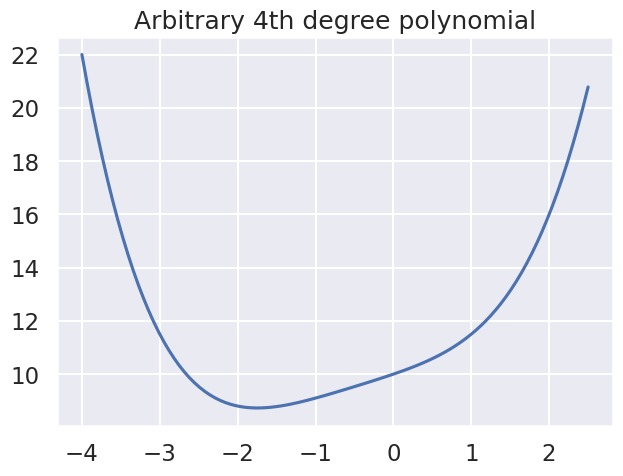

In [69]:
# Run this cell to plot a 4th degree polynomial; no further action is needed.
x_values = np.linspace(-4, 2.5, 100)

def fx(x):
    return 0.1 * x**4 + 0.2 * x**3 + 0.2 * x**2 + 1 * x + 10

plt.plot(x_values, fx(x_values));
plt.title("Arbitrary 4th degree polynomial");

By looking at the plot, we see that the x that minimizes the function is slightly larger than -2. What if we want the exact value? We will demonstrate how to grab the minimum value and the optimal `x` in the following cell.

The function `minimize` from [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) will attempt to minimize any function you throw at it. Try running the cell below, and you will see that `minimize` seems to get the answer correct.

Note: For today, we'll let `minimize` work as if by magic. We'll discuss how `minimize` works later in the course.

In [70]:
# Run this cell to minimize fx; no further action is required.
from scipy.optimize import minimize
minimize(fx, x0=1.1)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 8.728505719866614
        x: [-1.747e+00]
      nit: 6
      jac: [ 1.192e-07]
 hess_inv: [[ 5.088e-01]]
     nfev: 16
     njev: 8

**Notes:**

1. `fun`: The minimum value of the function. <br/>
2. `x`: The `x` which minimizes the function. We can index into the object returned by `minimize` to get these values. We have to add the additional `[0]` at the end because the minimizing `x` is returned as an array, but this is not necessarily the case for other attributes (i.e. `fun`), shown in the cell below. This means that `minimize` can also minimize multivariable functions, which we'll see in the second half of this lab.

In [71]:
# Run this cell to find the minimum and minimizer of fx; no further action is required.
min_result = minimize(fx, x0 =1.1)
min_of_fx = min_result['fun']
x_which_minimizes_fx = min_result['x'][0]
min_of_fx, x_which_minimizes_fx

(8.728505719866614, -1.746827786380178)

**Initial guess**: The parameter `x0` that we passed to the `minimize` function is where the `minimize` function starts looking as it tries to find the minimum. For example, above, `minimize` started its search at $x = 1.1$ because that's where we told it to start. For the function above, it doesn't really matter what $x$ we start at because the function is nice and has only a single local minimum. More technically, the function is nice because it is [convex](https://en.wikipedia.org/wiki/Convex_function), a property of functions that we will discuss in a later homework.

**Local minima**: `minimize` isn't perfect. For example, if we give it a function with many valleys (also known as local minima) it can get stuck. For example, consider the function below:

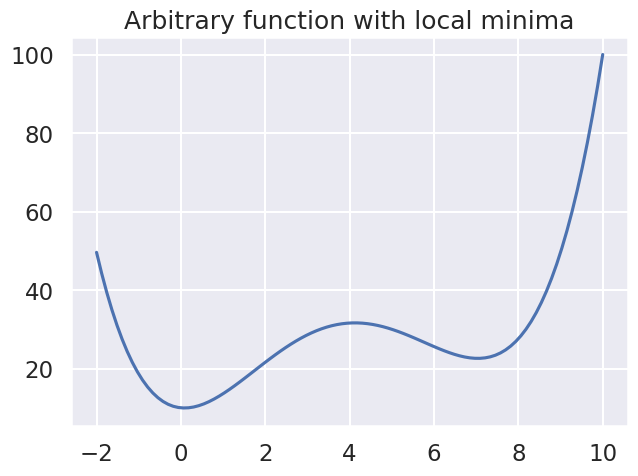

In [72]:
# Run this cell to plot fw; no further action is needed.
w_values = np.linspace(-2, 10, 100)

def fw(w):
    return 0.1 * w**4 - 1.5 * w**3 + 6 * w **2 - 1 * w + 10

plt.plot(w_values, fw(w_values));
plt.title("Arbitrary function with local minima");

If we start the minimization at $w = 6.5$, we'll get stuck in the local minimum at $w = 7.03$. Note that no matter what your actual variable is called in your function (`w` in this case), the `minimize` routine still expects a starting point parameter called `x0`.

In [73]:
# Run this cell to minimize fw starting at 6.5; no further action is needed.
minimize(fw, x0 = 6.5)    # Initial w = 6.5

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 22.594302881719777
        x: [ 7.038e+00]
      nit: 4
      jac: [ 0.000e+00]
 hess_inv: [[ 1.231e-01]]
     nfev: 12
     njev: 6

In [74]:
# Run this cell to minimize fw starting at 2; no further action is needed.
minimize(fw, x0 = 2)    # Initial w = 2

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 9.95742733908777
        x: [ 8.609e-02]
      nit: 6
      jac: [-1.073e-06]
 hess_inv: [[ 8.912e-02]]
     nfev: 16
     njev: 8

The `minimize` function can minimize functions of multiple variables (useful for numerically computing $\hat{\theta}_0$ and $\hat{\theta}_1$. There's one quirk, however, which is that the function has to accept its parameters as a single list, so we will define $\vec{\theta} = \begin{bmatrix}\theta_0\\ \theta_1 \end{bmatrix}$, as single list input to the function.

For example, consider the multivariate $f(u, v) = u^2 - 2 u v - 3 v + 2 v^2$. It turns out this function's minimum is at $(1.5, 1.5)$. To minimize this function, we create `f`.

In [75]:
# Run this cell to minimize f; no further action is needed.
def f(theta):
    u = theta[0]
    v = theta[1]
    return u**2 - 2 * u * v - 3 * v + 2 * v**2

minimize(f, x0 = [0.0, 0.0]) 

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -2.2499999999999982
        x: [ 1.500e+00  1.500e+00]
      nit: 3
      jac: [-5.960e-08  0.000e+00]
 hess_inv: [[ 1.000e+00  5.000e-01]
            [ 5.000e-01  5.000e-01]]
     nfev: 12
     njev: 4

<br/>

Now, let's use this approach to find a numerical solution to the optimal $\hat{\theta}$ that minimizes our MSE loss.

<br>

## Numerical Solution

Similar to the previous questions, we can use numerical optimization to estimate the optimal parameters.

<br>

---

### Question 1c

Using the `minimize` function, assign `theta0_hat_scipy` to the value of $\theta_0$ that minimizes the MSE for our `mpg` dataset. In other words, you want to find the exact minimum of the plot that you saw in the previous part.

**Notes:** 
* You should use the function you defined earlier: `mse_mpg_constant`.
* For autograding purposes, assign `theta0_hat_scipy` to the value of $\theta_0$ that minimizes the MSE according to the `minimize` function, called with initial `x0 = 0.0`.

In [76]:
# Call minimize with initial x0 = 0.0.
min_result = minimize(mse_mpg_constant, x0=0.0)
theta0_hat_scipy = min_result['x'][0]
theta0_hat_scipy

23.445918846437504

In [77]:
grader.check("q1c")

q1c results: All test cases passed!

<br>

## Analytical Solution

---

### Question 1d

As you saw in the lecture, we show that the value of $\theta_0$ that minimizes the MSE for the constant model is the average (mean) of the data. Assign `theta0_hat_analytical` to the mean of the observed `y_mpg` values, and compare this to the values you observed in questions 1b and 1c.

In [78]:
theta0_hat_analytical = np.mean(y_mpg)
theta0_hat_analytical

23.445918367346938

In [79]:
grader.check("q1d")

q1d results: All test cases passed!

Run the cell below to compare your results:

In [80]:
print('theta0_hat_observed: ', theta0_hat_observed)
print('theta0_hat_analytical: ', theta0_hat_analytical)
print('theta0_hat_numerical: ', theta0_hat_scipy)

theta0_hat_observed:  23.5
theta0_hat_analytical:  23.445918367346938
theta0_hat_numerical:  23.445918846437504


<br/>
Reflecting on Question 1, we used a 3-step approach to find the "best" summary statistic $\theta_0$:

A. Define the constant model $\hat{y}=\theta_0$.

B. Define "best": Define loss per datapoint ($L_2$ loss) and consequently define the model's loss $R(\theta_0)$ over a given data array as the Mean Squared Error (MSE).

C. Find the $\theta_0 = \hat{\theta_0}$ that minimizes the $R(\theta_0)$ in several ways:
* **Visually**: Create a plot of $R(\theta_0)$ vs. $\theta_0$ and eyeball the minimizing $\hat{\theta_0}$.
* **Numerically**: Create a function that returns $R(\theta_0)$ for the given data for a given $\theta_0$, and use the scipy `minimize` function to find the minimizing $\hat{\theta_0}$.
* **Analytically**: Use calculus to find $\hat{\theta_0}$ that minimizes MSE $R(\theta_0)$. Then compute $\hat{\theta_0}$ as the mean of the given data array, since this minimizes the defined $R(\theta_0)$.
    
At this point, you've hopefully convinced yourself that the mean of the data is the summary statistic that minimizes the MSE.

**Our prediction for every car's mpg**:

In [81]:
# Run this cell to define the prediction function, no further action needed.
def predict_mpg_constant():
    return theta0_hat_analytical

# Do not edit below this line.
print(f"""No matter what vehicle you have, Question 1 modeling process
    predicts that vehicle will have a mpg of {predict_mpg_constant():.2f}.""")

No matter what vehicle you have, Question 1 modeling process
    predicts that vehicle will have a mpg of 23.45.


<br/>
<hr style="border: 1px solid #fdb515;" />

# Question 2: Predicting Vehicle Efficiency with the Ordinary Least Squares (OLS) Method

In the previous questions, we observed that a constant model can give us some idea about vehicle efficiency. However, in the real world, we are often presented with more data associated with what we want to predict. Therefore, it is important to investigate more sophisticated methods that can be trained on many other features. One such method that we will explore is Ordinary Least Squares (OLS).   

In order to better understand OLS, it is worth investigating different ways to think about Simple Linear Regression (SLR) discussed earlier in the course.

let's re-formulate our SLR equation using linear algebra. We'll:

* Rewrite our $\theta$ coefficients as a vector $\theta = [\theta_0, \theta_1]$.
* Stack our $x_i$ values into a vector $\vec{x}$ with $n$ values.
* Stack our $y_i$ values into a vector $\mathbb{Y}$ of all $n$ observations in our sample.

Then our prediction vector $\hat{\mathbb{Y}}$ can then be written as:
$$\Large \hat{\mathbb{Y}} = {\theta_0} \vec{1}_n + {\theta_1} \vec{x} = \begin{bmatrix} | & | \\ \vec{1}_n & \vec{x} \\ | & | \end{bmatrix} \begin{bmatrix} {\theta_0} \\ {\theta_1} \end{bmatrix} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix} \begin{bmatrix} {\theta_0} \\ {\theta_1} \end{bmatrix} = \Bbb{X} \begin{bmatrix} {\theta_0} \\ {\theta_1} \end{bmatrix} = \mathbb{X} \theta$$

where $\mathbb{X} \in \mathbb{R}^{n\times2}$ is the **design matrix** with a **bias** column of all ones to account for the intercept, $\theta_0$, and one **feature** for all $n$ datapoints in our sample. 

Our equation now matches the Ordinary Least Squares (OLS) equation! 
$$\Large \hat{\mathbb{Y}} = \mathbb{X} \theta$$


### Expanding OLS to Multiple Linear Regression
The OLS equation can be expanded to cases when we have more than one feature, like in the case of our Multiple Linear Regression (MLR) model, where we can have $p$ features: 
$$\hat{y} = \theta_0 + \theta_1 x_1 + \dots + \theta_p x_p$$

Our OLS equation can be generalized as  
$$\Large \hat{\mathbb{Y}} = \begin{bmatrix} 
    1  & x_{1,1}  & x_{1,2}  & \cdots & x_{1,p}\\
    1  & x_{2,1}  & x_{2,2}    & \cdots & x_{2,p}\\
    \vdots & \vdots & \vdots & \ddots & \vdots\\
    1  & x_{n,1}  & x_{n,2}    & \cdots & x_{n,p}
\end{bmatrix}  
\begin{bmatrix} {\theta_0} \\ {\theta_1} \\ \vdots \\ \theta_{p} \end{bmatrix} = \mathbb{X} \theta
$$
with a
* **prediction vector** $\mathbb{Y} \in \mathbb{R}^{n}$,
* **design matrix** $\mathbb{X} \in \mathbb{R}^{n\times(p + 1)}$ representing the $p$ features for all $n$ datapoints in our sample,
* and a **parameter vector** $\theta \in \mathbb{R}^{p + 1}$.

Simple linear regression is a special case of OLS when $p=1$.

<br>

---

### Question 2a: Construct $\mathbb{X}$ with an intercept term
The OLS equation is displayed for your reference: 
$$\Large \hat{\mathbb{Y}} = \mathbb{X} \theta$$

Because we have an intercept term $\theta_0$ in our parameter vector $\theta$, our design matrix $\mathbb{X}$ needs a column with all-ones such that the resulting matrix expression, $\hat{\mathbb{Y}} = \mathbb{X} \theta$, represents $n$ linear equations, where equation $i$ is 
$$\hat{y_i} = \theta_0 \cdot 1 + \theta_1 \cdot x_{i, 1} + \dots + \theta_p \cdot x_{i, p}$$ 
where $x_{i, j}$ is the $j^{th}$ feature of the $i^{th}$ datapoint. The constant all-ones column of $\mathbb{X}$ is sometimes called the bias feature; $\theta_0$ is frequently called the **bias or intercept term**. 

> _Note:_ <span style="color:gray">
At other points in the course, and by convention, we may represent the model using an equivalent expression written without the index $i$, namely:
$$\hat{y} = \theta_0 + \theta_1 x_{1} + \dots + \theta_p x_{p}$$
> When written out like this, the symbols $x_{i, j}$ and $x_{j}$ are functionally identical - both refer to the $j^{th}$ feature of the $i^{th}$ datapoint. The $i$ is implicit in the case of the latter, but we are still talking in terms of numerical values, not vectors.
</span>


In order to construct the design matrix $\mathbb{X} \in \mathbb{R}^{n\times(p + 1)}$ from a given `DataFrame`, `X`, with a dimension of $n$ rows by $p$ columns, we need to augment our `DataFrame` with a column of ones.



<br/>

Below, implement `add_intercept`, which creates a design matrix such that the first (left-most) column is all ones. The function has two lines: you are responsible for constructing the all-ones column `bias_feature` using the `np.ones` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.ones.html?highlight=ones)). This is then piped into a call to `np.concatenate` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html)), which we've implemented for you.

**Note:** `bias_feature` should be a matrix of dimension `(n,1)`, not a vector of dimension `(n,)`.


In [82]:
def add_intercept(X):
    """
    Return X with a bias feature.
    
    Parameters
    -----------
    X: a 2D DataFrame of p numeric features
    (may also be a 2D NumPy array) of shape n x p
    
    Returns
    -----------
    A 2D matrix of shape n x (p + 1), where the leftmost
    column is a column vector of 1's.
    """
    bias_feature = np.ones(shape=(X.shape[0], 1))
    return np.concatenate([bias_feature, X], axis=1)

# Note the [[ ]] brackets below: the argument needs to be
# a matrix (DataFrame), as opposed to a single array (Series).
X = add_intercept(vehicle_data[['horsepower']])
X.shape

(392, 2)

In [83]:
grader.check("q2a")

q2a results: All test cases passed!

<br>

---
### Question 2b: Define the OLS Model

The predictions for all $n$ points in our data are:
$$ \Large \hat{\mathbb{Y}} = \mathbb{X}\theta $$
where $\theta = [\theta_0, \theta_1, \dots, \theta_p]$.

Below, implement the `linear_model` function to evaluate this product.

**Hint**: You can use `np.dot` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)), `pd.DataFrame.dot` ([documentation](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.dot.html)), or the `@` operator to multiply matrices/vectors.

In [84]:
def linear_model(thetas, X):
    """
    Return the linear combination of thetas and features as defined in the OLS equation.
    
    Parameters
    -----------
    thetas: a 1D vector representing the parameters of our model ([theta0, theta1, ...]).
    X: a 2D DataFrame of numeric features (may also be a 2D NumPy array).
    
    Returns
    -----------
    A 1D vector representing the linear combination of thetas and features as defined in the OLS equation.
    """
    return X @ thetas

In [85]:
grader.check("q2b")

q2b results: All test cases passed!

<br>

---

### Question 2c: Least Squares Estimate, Analytically

Recall from lecture that Ordinary Least Squares is when we fit a linear model using Mean Squared Error (MSE), which is equivalent to the following optimization problem:

$$\Large \min_{\theta} ||\Bbb{X}\theta - \Bbb{Y}||_2^2$$

We showed in lecture that when $X^TX$ is invertible, the optimal estimate, $\hat{\theta}$, is given by the equation:

$$ \Large \hat{\theta} = (\Bbb{X}^T\Bbb{X})^{-1}\Bbb{X}^T\Bbb{Y}$$

Below, implement the analytic solution to $\hat{\theta}$ using `np.linalg.inv` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)) to compute the inverse of $\Bbb{X}^T\Bbb{X}$.

**Hint 1**: To compute the transpose of a matrix, you can use `X.T` or `X.transpose()` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.T.html#numpy.ndarray.T)).

**Note:** You can also consider using `np.linalg.solve` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)) instead of `np.linalg.inv` because it is more robust (more on StackOverflow [here](https://stackoverflow.com/questions/31256252/why-does-numpy-linalg-solve-offer-more-precise-matrix-inversions-than-numpy-li)). 


In [86]:
def get_analytical_sol(X, y):
    """
    Computes the analytical solution to our
    least squares problem
    
    Parameters
    -----------
    X: a 2D DataFrame (or NumPy array) of numeric features.
    y: a 1D vector of outputs.
    
    Returns
    -----------
    The estimate for theta (a 1D vector) computed using the
    equation mentioned above.
    """
    return np.linalg.solve(X.T @ X, X.T @ Y)

Y = vehicle_data['mpg']
analytical_thetas = get_analytical_sol(X, Y)
analytical_thetas

array([39.93586102, -0.15784473])

In [87]:
grader.check("q2c")

q2c results: All test cases passed!

<br/>

Now, let's analyze our model's performance. Your task will be to interpret the model's performance using the two visualizations and one performance metric we've implemented below.

First, we run `sns.lmplot`, which will both provide a scatterplot of `mpg` vs `horsepower` and display the least-squares line of best fit. (If you'd like to verify the OLS fit you found above is the same line found through `Seaborn`, change `include_OLS` to `True`.)

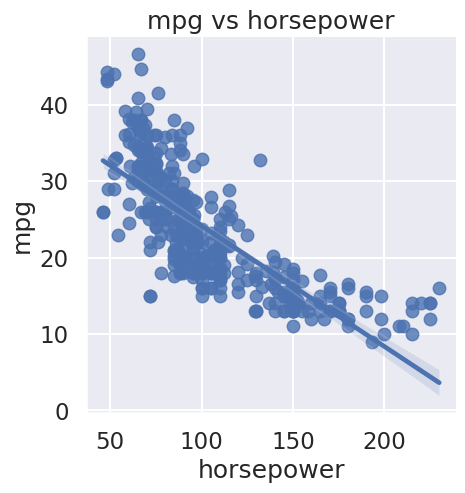

In [88]:
include_OLS = False # Change this flag to visualize OLS fit

sns.lmplot(data=vehicle_data, x='horsepower', y='mpg');
predicted_mpg_hp_only = linear_model(analytical_thetas, X)
if include_OLS:
    # if flag is on, add OLS fit as a dotted red line
    plt.plot(vehicle_data['horsepower'], predicted_mpg_hp_only, 'r--')
plt.title("mpg vs horsepower");

Next, we **plot the residuals.** While in Simple Linear Regression we have the option to plot residuals vs. the single input feature, in Multiple Linear Regression we often plot residuals vs. fitted values $\hat{\mathbb{Y}}$. In this lab, we opt for the latter.

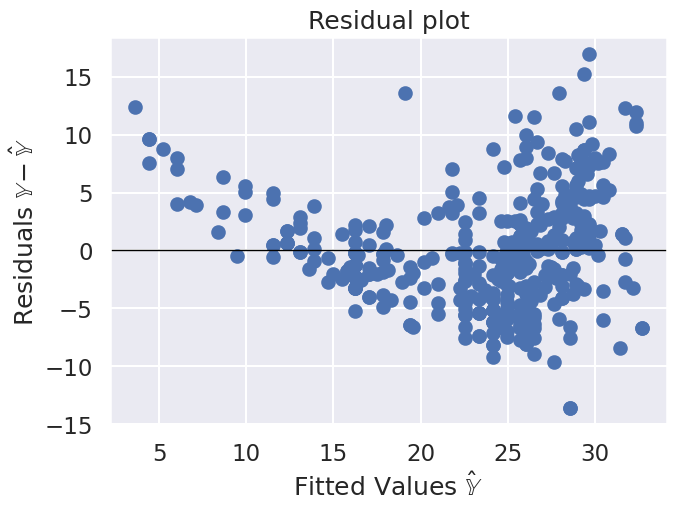

In [89]:
plt.scatter(predicted_mpg_hp_only, Y - predicted_mpg_hp_only)
plt.axhline(0, c='black', linewidth=1)
plt.xlabel(r'Fitted Values $\hat{\mathbb{Y}}$')
plt.ylabel(r'Residuals $\mathbb{Y} - \hat{\mathbb{Y}}$');
plt.title("Residual plot");

Finally, we compute the **correlation r** and **Multiple $R^2$** metric. As described in Lecture 12,

$$R^2 = \frac{\text{variance of fitted values}}{\text{variance of true } y} = \frac{\sigma_{\hat{y}}^2}{\sigma_y^2}$$

$R^2$  can be used
in the multiple regression setting, whereas $r$ (the correlation coefficient) is restricted to SLR since it depends on a single input feature.  In SLR, $r^{2}$ and Multiple $R^{2}$ are
equivalent; the proof is left to you.

In [90]:
r_hp_only = np.corrcoef(X[:, 1], Y)[0, 1]
r2_hp_only = r_hp_only ** 2
R2_hp_only = np.var(predicted_mpg_hp_only) / np.var(Y)

print('Correlation, r, using only horsepower: ', r_hp_only)
print('Correlation squared, r^2, using only horsepower: ', r2_hp_only)
print('Multiple R^2 using only horsepower: ', r2_hp_only)

Correlation, r, using only horsepower:  -0.7784267838977762
Correlation squared, r^2, using only horsepower:  0.6059482578894352
Multiple R^2 using only horsepower:  0.6059482578894352


**SOLUTION**
The r value of -0.778 (and R^2 value of 0.606) suggests a medium-strong negative correlation since it is within the middle range of [-1, 0]. We expect a uniform random residual plot if the linear model is a good fit, but both the scatterplot and the residual plot show a clear curvature, suggesting this linear model is not the best fit for our data. We may need a transformation first before fitting linear regression.

### Introduction to `sklearn`

Another way to fit a linear regression model is to use `scikit-learn`, an industry-standard package for machine learning applications. Because it is application-specific, `sklearn` is often faster and more robust than the analytical or `scipy`-based computation methods we've used thus far. Note that `scikit-learn` and `sklearn` refers to the same package, but it can only be imported under the name `sklearn`. We will use these two names interchangeably in this class.

To use `sklearn`:

1. Create an `sklearn` object.
1. `fit` the object to data.
1. Analyze fit or call `predict`.

##### **1. Create object.** 

We first create a `LinearRegression` object. Here's the `sklearn` [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Note that by default, the object will include an intercept term when fitting.

Here, `model` is like a "blank slate" for a linear model.

In [91]:
# 1. Run this cell to initialize a sklearn LinearRegression object.
from sklearn.linear_model import LinearRegression

# the `fit_intercept` argument controls whether or not the model should have an intercept (or bias) term
model = LinearRegression(fit_intercept=True)
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### **2. `fit` the object to data.** 

Now, we need to tell `model` to "fit" itself to the data. Essentially, this is doing exactly what you did in the previous part of this lab (creating a risk function and finding the parameters that minimize that risk).

**Note**: `X` needs to be a matrix (or `DataFrame`), as opposed to a single array (or `Series`) when running `model.fit`. This is because `sklearn.linear_model` is robust enough to be used for multiple regression, which we will look at later in this lab. This is why we use the double square brackets around `sqrt(hp)` when passing in the argument for `X`.

In [92]:
# 2. Run this cell to add sqrt(hp) column for each car in the dataset.
vehicle_data['sqrt(hp)'] = np.sqrt(vehicle_data['horsepower'])
vehicle_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,sqrt(hp)
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan,6.782330
102,26.0,4,97.0,46.0,1950,21.0,73,europe,volkswagen super beetle,6.782330
244,43.1,4,90.0,48.0,1985,21.5,78,europe,volkswagen rabbit custom diesel,6.928203
326,43.4,4,90.0,48.0,2335,23.7,80,europe,vw dasher (diesel),6.928203
325,44.3,4,90.0,48.0,2085,21.7,80,europe,vw rabbit c (diesel),6.928203


In [93]:
# 2. Run this cell to fit the model to the data.
model.fit(X = vehicle_data[['sqrt(hp)']], y = vehicle_data['mpg'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### **3. Analyze fit.** 

Now that the model exists, we can look at the $\hat{\theta}_0$ and $\hat{\theta}_1$ values it found, which are given in the attributes `intercept` and `coef`, respectively.

In [94]:
model.intercept_

58.705172037217494

In [95]:
model.coef_

array([-3.50352375])

To use the `sklearn` linear regression model to make predictions, you can use the `model.predict` method.

Below, we find the estimated `mpg` for a single datapoint with a `sqrt(hp)` of 6.78 (i.e., horsepower 46). Unlike the linear algebra approach, we do not need to manually add an intercept term because our `model` (which was created with `fit_intercept=True`) will automatically add one.

**Note:** You may receive a user warning about missing feature names. This is due to the fact that we fitted on the feature `DataFrame` `vehicle_data[['sqrt(hp)']]` with feature names `"sqrt(hp)"`, but only pass in a simple 2D array for prediction. To avoid this, we can convert our 2D array into a `DataFrame` with the matching feature name.

In [96]:
# Needs to be a 2D array since the X in step 2 was 2-dimensional.
single_datapoint = [[6.78]]
# Uncomment the following to see the result of predicting on a DataFrame instead of 2D array.
single_datapoint = pd.DataFrame([[6.78]], columns = ['sqrt(hp)']) # 
model.predict(single_datapoint) 

array([34.95128104])

<!-- BEGIN QUESTION -->

<br>

---

### Question 2d

Using the model defined above, which takes in `sqrt(hp)` as an input explanatory variable, predict the `mpg` for the full `vehicle_data` dataset. Assign the predictions to `predicted_mpg_hp_sqrt`. Running the cell will then compute the multiple $R^2$ value and create a linear regression plot for this new square root feature, overlaid on the original least squares estimate (used in Question 2c).

Multiple R^2 using sqrt(hp):  0.6437035832706475


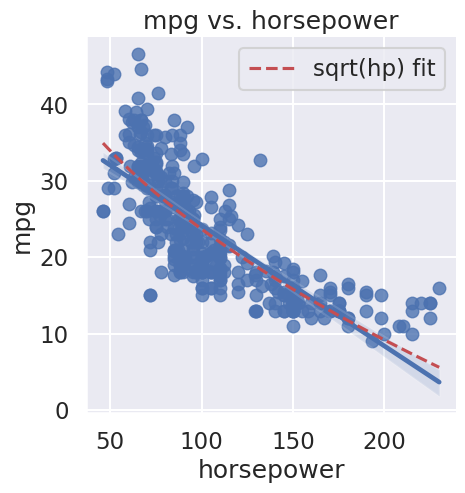

In [97]:
predicted_mpg_hp_sqrt = model.predict(vehicle_data[['sqrt(hp)']])

# Do not modify below this line.
r2_hp_sqrt = np.var(predicted_mpg_hp_sqrt) / np.var(vehicle_data['mpg'])
print('Multiple R^2 using sqrt(hp): ', r2_hp_sqrt)

sns.lmplot(x = 'horsepower', y = 'mpg', data = vehicle_data)
plt.plot(vehicle_data['horsepower'],  predicted_mpg_hp_sqrt,
         color = 'r', linestyle='--', label='sqrt(hp) fit');
plt.title("mpg vs. horsepower")
plt.legend();

<!-- END QUESTION -->

The visualization shows a slight improvement, but the points on the scatter plot are still more "curved" than our prediction line. Let's try a quadratic feature instead! 

Next, we use the power of OLS to **add an additional feature.** Questions 2 utilized simple linear regression, a special case of OLS where we have 1 feature ($p=1$). For the following questions, we'll utilize multiple linear regression, which are cases of OLS when we have more than 1 features ($p > 1$). 

<br/>
<hr style="border: 1px solid #fdb515;" />

## Add an Additional Feature

For the second part of this lab, we move from SLR to multiple linear regression.

Until now, we have established relationships between one independent explanatory variable and one response variable. However, with real-world problems, you will often want to use **multiple features** to model and predict a response variable. Multiple linear regression attempts to model the relationship between two or more explanatory variables and a response variable by fitting a linear equation to the observed data.

We can consider including functions of existing features as **new features** to help improve the predictive power of our model. (This is something we will discuss in further detail in the Feature Engineering lecture.)

The cell below adds a column that contains the square of the horsepower for each car in the dataset.

In [98]:
# Run this cell to add a column of horsepower squared, no further action needed.
vehicle_data['hp^2'] = vehicle_data['horsepower'] ** 2
vehicle_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,sqrt(hp),hp^2
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan,6.782330,2116.0
102,26.0,4,97.0,46.0,1950,21.0,73,europe,volkswagen super beetle,6.782330,2116.0
244,43.1,4,90.0,48.0,1985,21.5,78,europe,volkswagen rabbit custom diesel,6.928203,2304.0
326,43.4,4,90.0,48.0,2335,23.7,80,europe,vw dasher (diesel),6.928203,2304.0
325,44.3,4,90.0,48.0,2085,21.7,80,europe,vw rabbit c (diesel),6.928203,2304.0


<br>

---
# Question 3

### Question 3a

Using `sklearn`'s `LinearRegression`, create and fit a model that tries to predict `mpg` from `horsepower` AND `hp^2` using the `DataFrame` `vehicle_data`. Name your model `model_multi`.

**Hint**: It should follow a similar format as Question 2.

**Note**: You must create a new model again using `LinearRegression()`, otherwise the old model from Question 2 will be overwritten. If you do overwrite it, don't fret! Just restart your kernel and run your cells in order. If you are unsure why this overwriting happens, please review [object-oriented programming](https://cs61a.org/study-guide/objects/) from CS61A.

In [99]:
model_multi = LinearRegression() # By default, fit_intercept=True
model_multi.fit(X = vehicle_data[['horsepower', 'hp^2']], y = vehicle_data['mpg'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
grader.check("q3a")

q3a results: All test cases passed!

After fitting, we can see the coefficients and intercept. Note that there are now two elements in `model_multi.coef_`, since there are two features.

In [101]:
model_multi.intercept_

56.90009970211294

In [102]:
model_multi.coef_

array([-0.46618963,  0.00123054])

<!-- BEGIN QUESTION -->

<br>

---

### Question 3b

Using the above values, write out the function that the model is using to predict `mpg` from `horsepower` and `hp^2`.


`mpg` = -0.46618963 * `horsepower` + 0.00123054 * `hp^2` + 56.90009970211294

<!-- END QUESTION -->

<br/>

The plot below shows the prediction of our model. It's much better!

Multiple R^2 using both horsepower and horsepower squared:  0.6875590305127515


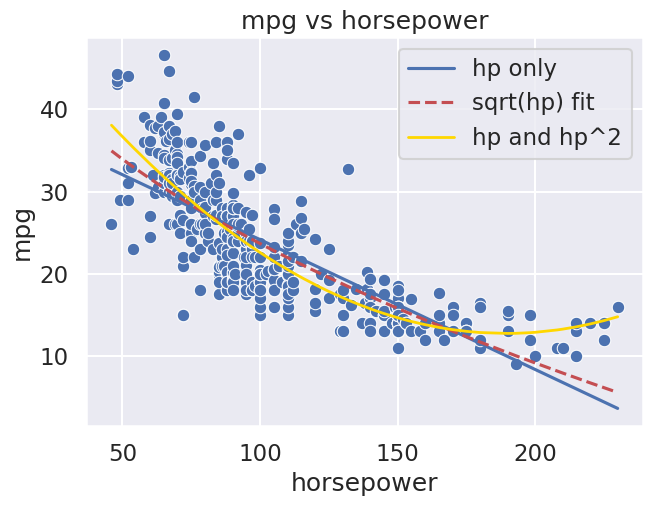

In [103]:
# Run this cell to show the prediction of our model.
predicted_mpg_multi = model_multi.predict(vehicle_data[['horsepower', 'hp^2']])
r2_multi = np.var(predicted_mpg_multi) / np.var(vehicle_data['mpg'])
print('Multiple R^2 using both horsepower and horsepower squared: ', r2_multi)

sns.scatterplot(x = 'horsepower', y = 'mpg', data = vehicle_data)
plt.plot(vehicle_data['horsepower'],  predicted_mpg_hp_only, label='hp only');
plt.plot(vehicle_data['horsepower'],  predicted_mpg_hp_sqrt, color = 'r', linestyle='--', label='sqrt(hp) fit');
plt.plot(vehicle_data['horsepower'],  predicted_mpg_multi, color = 'gold', linewidth=2, label='hp and hp^2');
plt.title("mpg vs horsepower")
plt.legend();

By incorporating a squared feature, we are able to capture the curvature of the dataset. Our model is now a parabola centered on our data. 

<br>

---

## Question 3c

In the cell below, we assign the mean of the `mpg` column of the `vehicle_data` `DataFrame` to `mean_mpg`. Given this information, what is the mean of the `mean_predicted_mpg_hp_only`, `predicted_mpg_hp_sqrt`, and `predicted_mpg_multi` arrays?

**Hint**: Your answer should be a function of `mean_mpg` provided, you should not have to call `np.mean` in your code.


In [104]:
mean_mpg = np.mean(vehicle_data['mpg'])
mean_predicted_mpg_hp_only = np.mean(predicted_mpg_hp_only)
mean_predicted_mpg_hp_sqrt = np.mean(predicted_mpg_hp_sqrt)
mean_predicted_mpg_multi = np.mean(predicted_mpg_multi)

In [105]:
grader.check("q3c")

q3c results: All test cases passed!

Comparing this model with previous models:

In [106]:
# Compares q1, q2, q3, and overfit models (ignores redundant model)
print('Multiple R^2 using only horsepower: ', r2_hp_only)
print('Multiple R^2 using sqrt(hp): ', r2_hp_sqrt)
print('Multiple R^2 using both hp and hp^2: ', r2_multi)

Multiple R^2 using only horsepower:  0.6059482578894352
Multiple R^2 using sqrt(hp):  0.6437035832706475
Multiple R^2 using both hp and hp^2:  0.6875590305127515


Observe that the R^2 value of the last model is the highest. In fact, it can be proven that multiple R^2 will not decrease as we add more variables. You may be wondering, what will happen if we add more variables? We will discuss the limitations of adding too many variables in an upcoming lecture. Below, we consider an extreme case where we include a variable twice in the model.

You might also be wondering why we chose to use `hp^2` as our additional feature, even though that transformation in the Tukey-Mosteller Bulge Diagram doesn't correspond to the bulge in our data. The Bulge diagram is a good starting point for transforming our data, but you may need to play around with different transformations to see which of them is able to capture the true relationship in our data and create a model with the best fit. This trial and error process is a very useful technique used all throughout data science!

<br/>
<hr style="border: 1px solid #fdb515;" />

## Faulty Feature Engineering: Redundant Features

Suppose we used the following linear model:

\begin{align}
\text{mpg} &= \theta_0 + \theta_1 \cdot \text{horsepower} + \theta_2 \cdot \text{horsepower}^2 + \theta_3 \cdot \text{horsepower}
\end{align}

Notice that `horsepower` appears twice in our model!! We will explore how this redundant feature affects our modeling.

<br>

---

## Question 4

### Question 4a: Linear Algebra

Construct a matrix `X_redundant` that uses the `vehicle_data` `DataFrame` to encode the "three" features above, as well as a bias feature.

**Hint**: Use the `add_intercept` term you implemented in Question 1a.


In [107]:
X_redundant = add_intercept(vehicle_data[['horsepower', 'hp^2', 'horsepower']])
X_redundant.shape

(392, 4)

In [108]:
grader.check("q4a")

q4a results: All test cases passed!

<br>

Now, run the cell below to find the analytical OLS Estimate. Notice we are not be using the `get_analytical_sol` function you wrote in Question 1c. Instead, we are using the scipy.linalg.solve function [(documentation)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve.html).

**Note:** You should see an **Ill-conditioned matrix Warning**. This is by design, and this cell is supposed to illustrate that calculating the $\theta$s this way will not be accurate.

In [109]:
# Run this cell to check the result, no further action needed. 
# The try-except block suppresses errors during submission
import traceback
try:
    xTx = X_redundant.T.dot(X_redundant)
    xTy = X_redundant.T.dot(vehicle_data['mpg'])
    analytical_thetas = scipy.linalg.solve(xTx, xTy)
    # analytical_thetas = get_analytical_sol(X_redundant, vehicle_data['mpg'])
except Exception as e:
    print(traceback.format_exc())

/tmp/ipykernel_105/1460606428.py:7: LinAlgWarning: Ill-conditioned matrix (rcond=3.24711e-21): result may not be accurate.
  analytical_thetas = scipy.linalg.solve(xTx, xTy)


<!-- BEGIN QUESTION -->

---

### Question 4b

In the cell below, explain why we got the error above when trying to calculate the analytical solution to predict `mpg`.


The design matrix $X$ is singular (not full rank), which contributes to the error on calculation of inverse of $X^TX$.

<!-- END QUESTION -->

Note: While we encountered errors when using the linear algebra approach, a model fitted with `sklearn` will not encounter matrix singularity errors since it uses numerical methods to find optimal values of $\theta$ (to be covered in the Gradient Descent lecture).

In [110]:
# sklearn finds optimal parameters despite redundant features
model_redundant = LinearRegression(fit_intercept=False) # X_redundant already has an intercept column
model_redundant.fit(X = X_redundant, y = vehicle_data['mpg'])
model_redundant.coef_

array([ 5.69000997e+01, -2.33094815e-01,  1.23053610e-03, -2.33094815e-01])

<br/><br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Congratulations! You have finished Lab 05!

### Course Content Feedback

If you have any feedback about this assignment or about any of our other weekly, weekly assignments, lectures, or discussions, please fill out the [Course Content Feedback Form](https://docs.google.com/forms/d/e/1FAIpQLSelI7jXeKh6eYqWnpEsJVPSuRL0JWZ2yjLNbZJMxekUquDetA/viewform?usp=dialog). Your input is valuable in helping us improve the quality and relevance of our content to better meet your needs and expectations!

### Submission Instructions

Below, you will see a cell. Running this cell will automatically generate a zip file with your autograded answers. Submit this file to the Lab 05 assignment on Pensive. If you run into any issues when running this cell, feel free to check this [section](https://ds100.org/debugging-guide/autograder-gradescope/#why-does-the-last-grader-export-cell-fail-if-all-previous-tests-passed) in the Data 100 Debugging Guide.

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [111]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False, run_tests=True)

Running your submission against local test cases...


Your submission received the following results when run against available test cases:

    q1a results: All test cases passed!

    q1b results: All test cases passed!

    q1c results: All test cases passed!

    q1d results: All test cases passed!

    q2a results: All test cases passed!

    q2b results: All test cases passed!

    q2c results: All test cases passed!

    q3a results: All test cases passed!

    q3c results: All test cases passed!

    q4a results: All test cases passed!
